In [1]:
import pandas as pd
df = pd.read_csv(r'Exam_Score_Prediction.csv', encoding = "latin1")

In [2]:
df.info() 
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  float64
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(5), int64(1), object(7)
memory usage: 2.0+ MB


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.500000,20.473300,4.007604,70.017365,7.00856,62.513225
std,5770.211372,2.284458,2.308313,17.282262,1.73209,18.908491
min,200.990000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,19800.010000,24.000000,7.910000,99.400000,9.90000,100.000000


In [6]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [7]:
df.shape

(20000, 13)

In [8]:
df.duplicated().sum()

0

In [12]:
# Drop the identifier column before encoding
df.drop('student_id', axis=1, inplace=True)

In [13]:
# Convert all categorical text columns into numerical columns using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Print the new shape to confirm the number of columns increased
print("Encoded DataFrame Shape:", df_encoded.shape)

Encoded DataFrame Shape: (20000, 24)


In [14]:
# Define X (Features: all columns except exam_score)
X = df_encoded.drop('exam_score', axis=1)

# Define y (Target: the column we want to predict)
y = df_encoded['exam_score']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (20000, 23)
y Shape: (20000,)


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

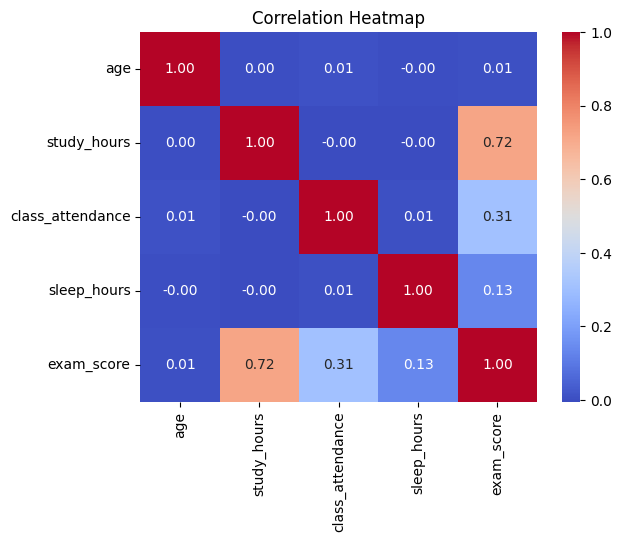

In [25]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

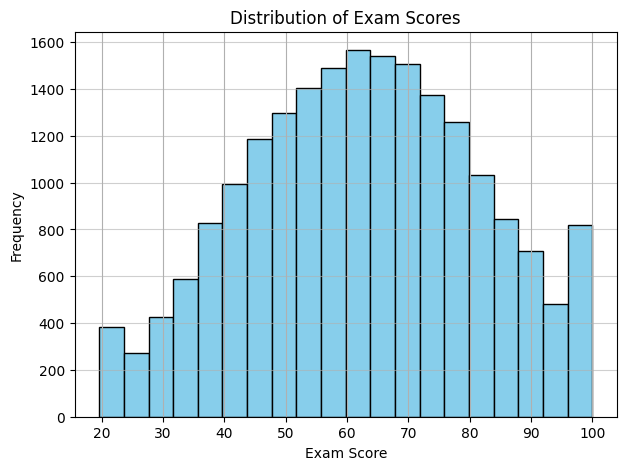

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
df['exam_score'].hist(bins=20, edgecolor='black', color='skyblue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.6)
plt.savefig('histogram_exam_score.png')
plt.show()

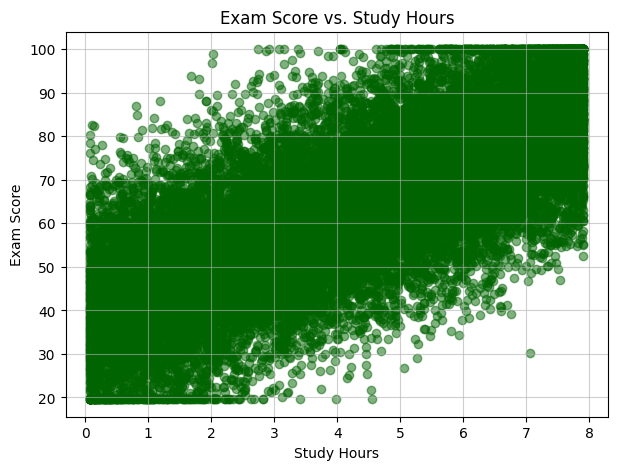

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df['study_hours'], df['exam_score'], alpha=0.5, color='darkgreen')
plt.title('Exam Score vs. Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(alpha=0.6)
plt.savefig('scatter_study_hours.png')
plt.show()

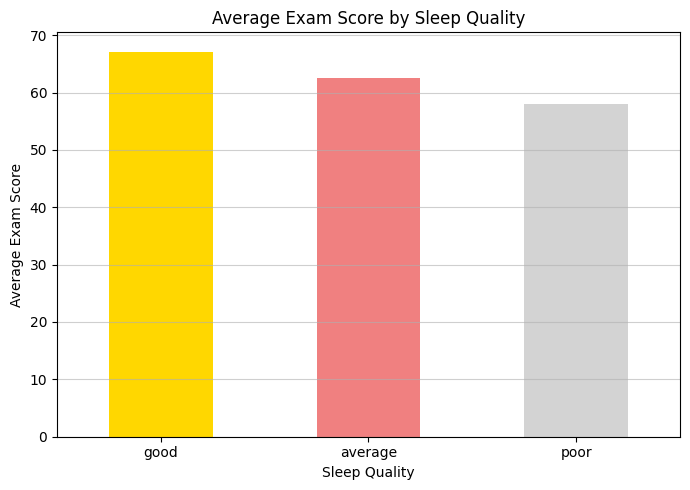

In [28]:
import matplotlib.pyplot as plt

# Calculate mean scores for each group
mean_scores_sleep = df.groupby('sleep_quality')['exam_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
mean_scores_sleep.plot(kind='bar', color=['gold', 'lightcoral', 'lightgray'])
plt.title('Average Exam Score by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Average Exam Score')
plt.xticks(rotation=0) # Keep labels horizontal
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.savefig('bar_sleep_quality.png')
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

scaler_std = StandardScaler()

X_train_standardized = X_train.copy()
X_train_standardized.loc[:, numerical_cols] = scaler_std.fit_transform(X_train[numerical_cols])

X_test_standardized = X_test.copy()
X_test_standardized.loc[:, numerical_cols] = scaler_std.transform(X_test[numerical_cols])

print("Standardization complete.")

Standardization complete.
